In [147]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

In [148]:
df = pd.read_csv("/home/umoujahid/visualisation_project/data/Global-YouTube-Statistics_duplicates_dropped.csv")

In [149]:
df.head()

,rank,Youtuber,subscribers,video views,category,Title,uploads,Country,Abbreviation,channel_type,...,subscribers_for_last_30_days,created_year,created_month,created_date,Gross tertiary education enrollment (%),Population,Unemployment rate,Urban_population,Latitude,Longitude
0,1,T-Series,245000000,2.280000e+11,Music,T-Series,20082,India,IN,Music,...,2000000.0,2006.0,Mar,13.0,28.1,1.366418e+09,5.36,471031528.0,20.593684,78.962880
1,2,YouTube Movies,170000000,0.000000e+00,Film & Animation,youtubemovies,1,United States,US,Games,...,NaN,2006.0,Mar,5.0,88.2,3.282395e+08,14.70,270663028.0,37.090240,-95.712891
2,3,MrBeast,166000000,2.836884e+10,Entertainment,MrBeast,741,United States,US,Entertainment,...,8000000.0,2012.0,Feb,20.0,88.2,3.282395e+08,14.70,270663028.0,37.090240,-95.712891
3,4,Cocomelon - Nursery Rhymes,162000000,1.640000e+11,Education,Cocomelon - Nursery Rhymes,966,United States,US,Education,...,1000000.0,2006.0,Sep,1.0,88.2,3.282395e+08,14.70,270663028.0,37.090240,-95.712891
4,5,SET India,159000000,1.480000e+11,Shows,SET India,116536,India,IN,Entertainment,...,1000000.0,2006.0,Sep,20.0,28.1,1.366418e+09,5.36,471031528.0,20.593684,78.962880


In [150]:
# drop  entire rows where the target column has missing values
df.dropna(subset=["created_year"],inplace = True)

In [151]:
df.isna().sum()

rank                                         0
Youtuber                                     0
subscribers                                  0
video views                                  0
category                                    46
Title                                        0
uploads                                      0
Country                                    120
Abbreviation                               120
channel_type                                27
video_views_rank                             0
country_rank                               114
channel_type_rank                           29
video_views_for_the_last_30_days            51
lowest_monthly_earnings                      0
highest_monthly_earnings                     0
lowest_yearly_earnings                       0
highest_yearly_earnings                      0
subscribers_for_last_30_days               332
created_year                                 0
created_month                                0
created_date 

In [152]:
years = df["created_year"].unique()
years

array([2006., 2012., 2013., 2015., 2010., 2016., 2018., 2014., 2007.,
       2020., 2008., 2005., 2011., 2009., 2017., 2021., 1970., 2019.,
       2022.])

In [153]:
# drop the outlier 1970 (impossible )
df.drop(df[df["created_year"] == years[-3]].index, inplace=True)

In [154]:
df["created_year"].unique()

array([2006., 2012., 2013., 2015., 2010., 2016., 2018., 2014., 2007.,
       2020., 2008., 2005., 2011., 2009., 2017., 2021., 2019., 2022.])

In [155]:
## transform the columns created_year & created_date to integers inplace of object
df["created_year"] = df["created_year"].astype(int)
df["created_date"] = df["created_date"].astype(int)

In [156]:
# create the column complete_date by combinng the columns created date , month and year , using time series method in pandas
df["created_complete_date"] = pd.to_datetime(df["created_year"].astype(str) 
                                             + "-" + df["created_month"].astype(str) 
                                             + "-" + df["created_date"].astype(str) ,
                                             format="%Y-%b-%d" ,dayfirst=False).apply(lambda x: x.strftime("%Y"))

In [157]:
df["created_complete_date"]

0      2006
1      2006
2      2012
3      2006
4      2006
       ... 
990    2017
991    2018
992    2006
993    2012
994    2017
Name: created_complete_date, Length: 989, dtype: object

In [158]:
# transform the month column to the correct format
df["created_month"] = pd.to_datetime(df["created_month"].astype(str) , format="%b" , dayfirst=False).apply(lambda x : x.strftime("%m"))

<div style="
    background: linear-gradient(135deg, #f8fafc, #eef2ff);
    border-left: 6px solid #4f46e5;
    padding: 22px;
    border-radius: 14px;
    font-family: 'Segoe UI', Arial, sans-serif;
    box-shadow: 0 4px 14px rgba(0,0,0,0.08);
">

<h2 style="color:purple; margin-bottom:10px;">
    line plot of number of channel created by year
</h2>

</div>

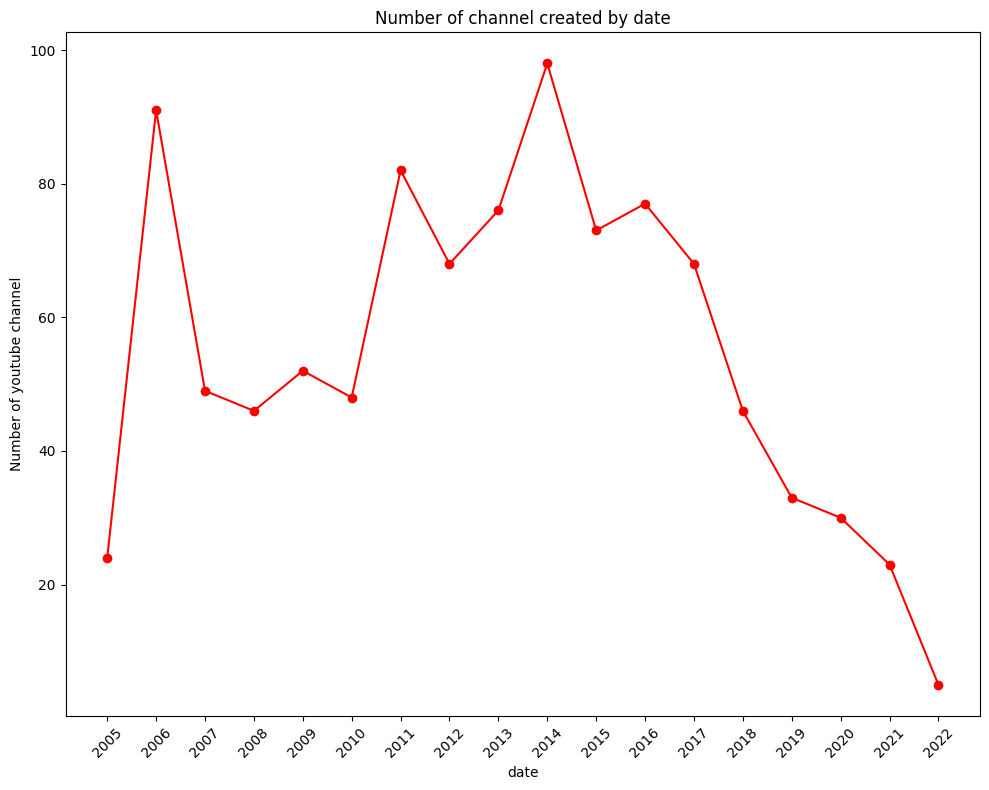

In [159]:
grouped = df.groupby("created_complete_date")["Youtuber"].count()

x = list(grouped.index)
y = list(grouped.values)
w = list(df.groupby("channel_type")["video_views_for_the_last_30_days"].sum()/1e9)

plt.figure(figsize=(10, 8))
plt.plot(x, y , marker='o', linestyle='-', color='r')
plt.title("Number of channel created by date")
plt.xlabel("date")
plt.ylabel("Number of youtube channel")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

<div style="
    background: linear-gradient(135deg, #f8fafc, #eef2ff);
    border-left: 6px solid #4f46e5;
    padding: 22px;
    border-radius: 14px;
    font-family: 'Segoe UI', Arial, sans-serif;
    box-shadow: 0 4px 14px rgba(0,0,0,0.08);
">

<h2 style="color:purple; margin-bottom:10px;">
    line plot of Total Video Views (in Billions) by Year of Channel Creation
</h2>

</div>

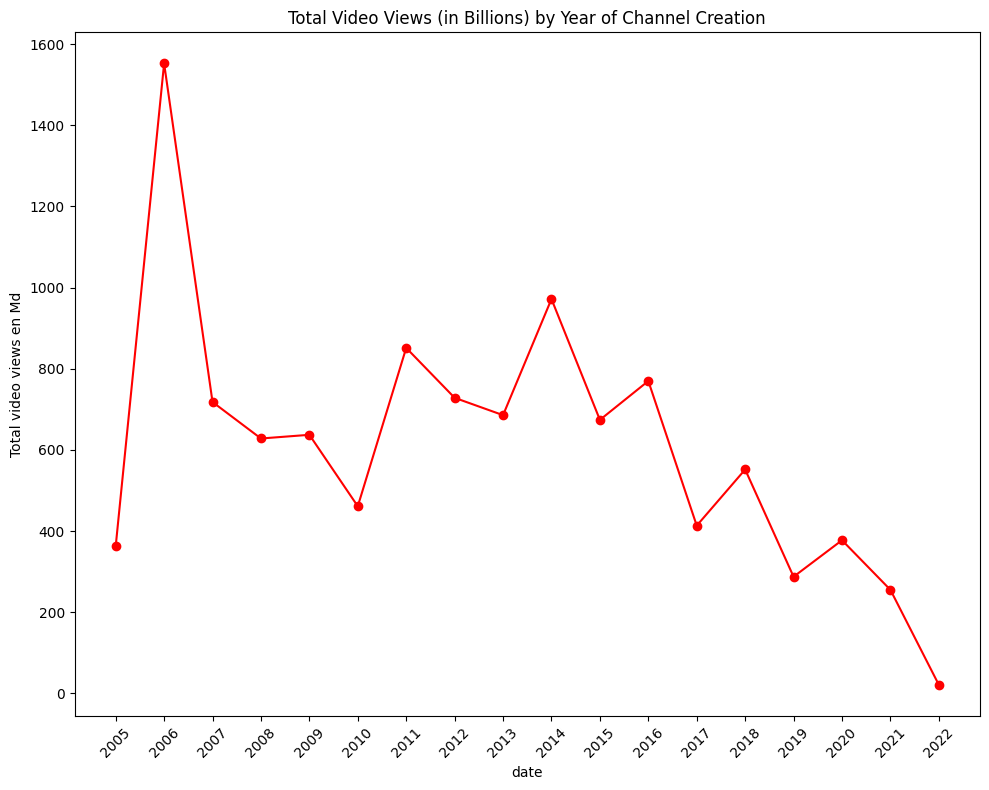

In [160]:
grouped = df.groupby("created_complete_date")["video views"].sum().apply(lambda x : x /1e9)

x = list(grouped.index)
y = list(grouped.values)

plt.figure(figsize=(10, 8))
plt.plot(x, y , marker='o', linestyle='-', color='r')
plt.title("Total Video Views (in Billions) by Year of Channel Creation")
plt.xlabel("date")
plt.ylabel("Total video views en Md")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

---
- on remarque que les chaînes les plus anciennes génèrent généralement un nombre de vues beaucoup plus élevé que les chaînes les plus récentes. Cela peut s’expliquer par le fait qu’elles ont eu plus de temps pour publier du contenu, construire une audience fidèle et accumuler des vues au fil des années.
---

<div style="
    background: linear-gradient(135deg, #f8fafc, #eef2ff);
    border-left: 6px solid #4f46e5;
    padding: 22px;
    border-radius: 14px;
    font-family: 'Segoe UI', Arial, sans-serif;
    box-shadow: 0 4px 14px rgba(0,0,0,0.08);
">

<h2 style="color:purple; margin-bottom:10px;">
     Courbe par période - video views
</h2>

</div>

In [161]:
# Transform values to billion to normalize the column
data = df.copy()
data["video views"] = data["video views"].apply(lambda x : x / 1e9)

In [162]:
# Moyenne des views par mois et par année
courbe_periode = data.groupby(["created_year", "created_month"] )["video views"].mean().unstack()  ## the indexes ( year & month) turn to labels
courbe_periode

created_month,01,02,03,04,05,06,07,08,09,10,11,12
created_year,,,,,,,,,,,,
2005,NaN,NaN,NaN,NaN,NaN,7.719450,NaN,NaN,12.388146,14.049172,14.495019,27.496747
2006,8.516085,3.347126,25.963440,15.372657,8.527945,15.256363,8.804935,17.113625,45.065967,9.696982,11.475295,10.878863
2007,13.342716,15.625374,6.575413,12.989582,25.351023,14.932086,11.714763,101.000000,9.353054,5.645433,6.167161,12.607489
2008,13.131282,12.221181,11.201338,9.821134,13.123631,18.671315,20.026062,8.870790,9.033826,NaN,15.676229,NaN
2009,NaN,8.526200,8.258300,7.102966,19.269294,10.031079,6.662000,11.291329,14.949305,11.778895,11.439554,14.643284
2010,9.764066,2.154149,16.074181,11.215175,11.025406,13.615375,5.118180,2.753771,9.923944,10.183272,14.002336,9.401802
2011,8.982491,10.919285,7.879161,5.429896,12.788512,25.934534,6.236249,7.763901,9.635121,9.178041,7.322587,14.310660
2012,8.379895,12.662697,14.067226,12.457677,10.336027,6.090371,8.815913,9.358136,12.570294,7.481190,13.988064,9.334421
2013,11.465148,17.893122,8.823663,3.740681,12.287821,10.030703,6.077422,7.236484,5.318108,9.832748,13.684336,1.922000


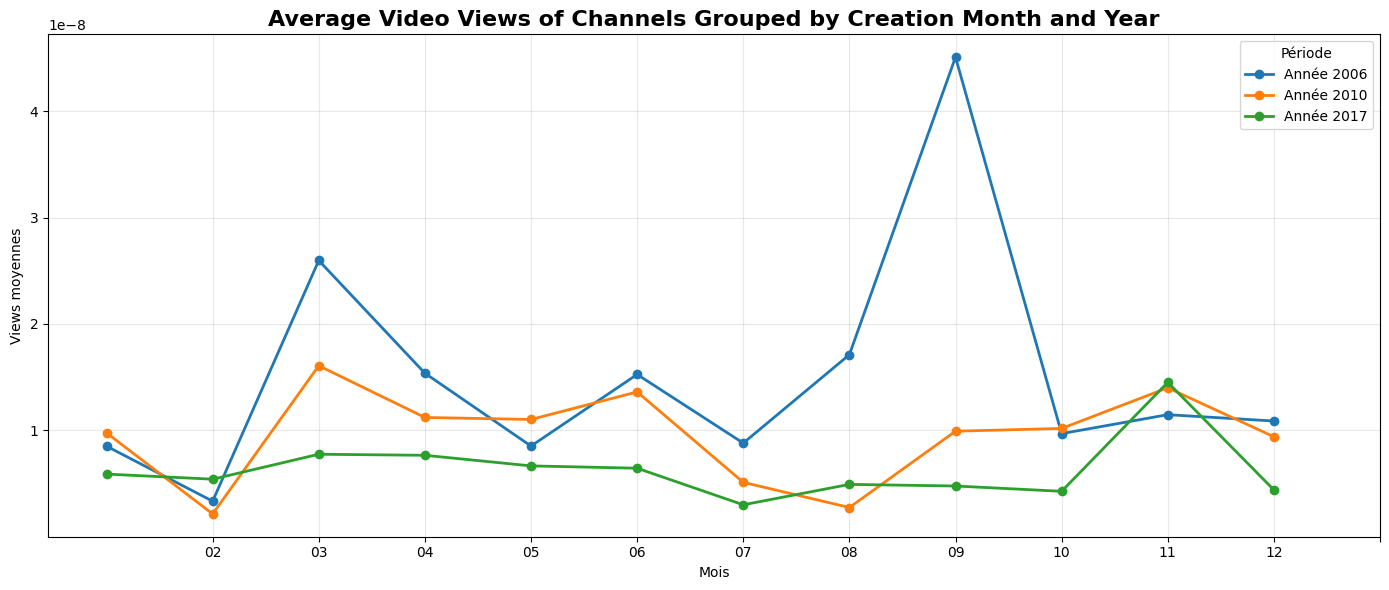

In [163]:
# keep just the years 2006, 2010, 2017
periode_2006_2010_2017 = courbe_periode[
    courbe_periode.index.isin([2006, 2010, 2017])
]

# Tracé
plt.figure(figsize=(14, 6))

for annee in periode_2006_2010_2017.index:
    plt.plot(
        periode_2006_2010_2017.columns,
        periode_2006_2010_2017.loc[annee].apply(lambda x : x / 1e9),
        marker="o",
        linewidth=2,
        label=f"Année {annee}"
    )

plt.title("Average Video Views of Channels Grouped by Creation Month and Year", fontsize=16, weight="bold")
plt.xlabel("Mois")
plt.ylabel("Views moyennes")

plt.xticks(range(1, 13) , )

plt.legend(title="Période")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

---
- De manière générale, après avoir regroupé les chaînes YouTube selon leur mois et leur année de création, on remarque que le facteur temps influence directement le volume de vues générées. Les chaînes créées en 2006 présentent globalement des valeurs de video views plus élevées que celles créées en 2010, qui elles-mêmes dépassent généralement celles créées en 2017.

- Cette tendance peut s’expliquer par le fait que les chaînes les plus anciennes ont eu plus de temps pour publier du contenu, développer leur audience et accumuler des vues au fil des années.

- Au-delà de l'effet de l'ancienneté, le graphique des vues moyennes révèle également des effets de mois de création. Les chaînes créées en mars enregistrent systématiquement des vues moyennes plus élevées pour les trois années étudiées, tandis que celles créées en février présentent un creux qualitatif cohérent sur l'ensemble des années. On note également un pic exceptionnel en septembre 2006, qui ne se reproduit pas pour 2010 et 2017 et s'apparente davantage à une anomalie historique liée aux débuts de YouTube qu'à un effet saisonnier généralisable. Il convient donc de parler d'effets de mois plutôt que de saisonnalité au sens strict, ces effets restant partiels et non uniformes selon les années.
---

<div style="
    background: linear-gradient(135deg, #f8fafc, #eef2ff);
    border-left: 6px solid #4f46e5;
    padding: 22px;
    border-radius: 14px;
    font-family: 'Segoe UI', Arial, sans-serif;
    box-shadow: 0 4px 14px rgba(0,0,0,0.08);
">

<h2 style="color:purple; margin-bottom:10px;">
     Courbe par période - subscribers
</h2>

</div>

In [164]:
# Moyenne des views par mois et par année
courbe_periode1 = data.groupby(["created_year", "created_month"] )["subscribers"].mean().unstack()  ## the indexes ( year & month) turn to labels
courbe_periode

created_month,01,02,03,04,05,06,07,08,09,10,11,12
created_year,,,,,,,,,,,,
2005,NaN,NaN,NaN,NaN,NaN,7.719450,NaN,NaN,12.388146,14.049172,14.495019,27.496747
2006,8.516085,3.347126,25.963440,15.372657,8.527945,15.256363,8.804935,17.113625,45.065967,9.696982,11.475295,10.878863
2007,13.342716,15.625374,6.575413,12.989582,25.351023,14.932086,11.714763,101.000000,9.353054,5.645433,6.167161,12.607489
2008,13.131282,12.221181,11.201338,9.821134,13.123631,18.671315,20.026062,8.870790,9.033826,NaN,15.676229,NaN
2009,NaN,8.526200,8.258300,7.102966,19.269294,10.031079,6.662000,11.291329,14.949305,11.778895,11.439554,14.643284
2010,9.764066,2.154149,16.074181,11.215175,11.025406,13.615375,5.118180,2.753771,9.923944,10.183272,14.002336,9.401802
2011,8.982491,10.919285,7.879161,5.429896,12.788512,25.934534,6.236249,7.763901,9.635121,9.178041,7.322587,14.310660
2012,8.379895,12.662697,14.067226,12.457677,10.336027,6.090371,8.815913,9.358136,12.570294,7.481190,13.988064,9.334421
2013,11.465148,17.893122,8.823663,3.740681,12.287821,10.030703,6.077422,7.236484,5.318108,9.832748,13.684336,1.922000


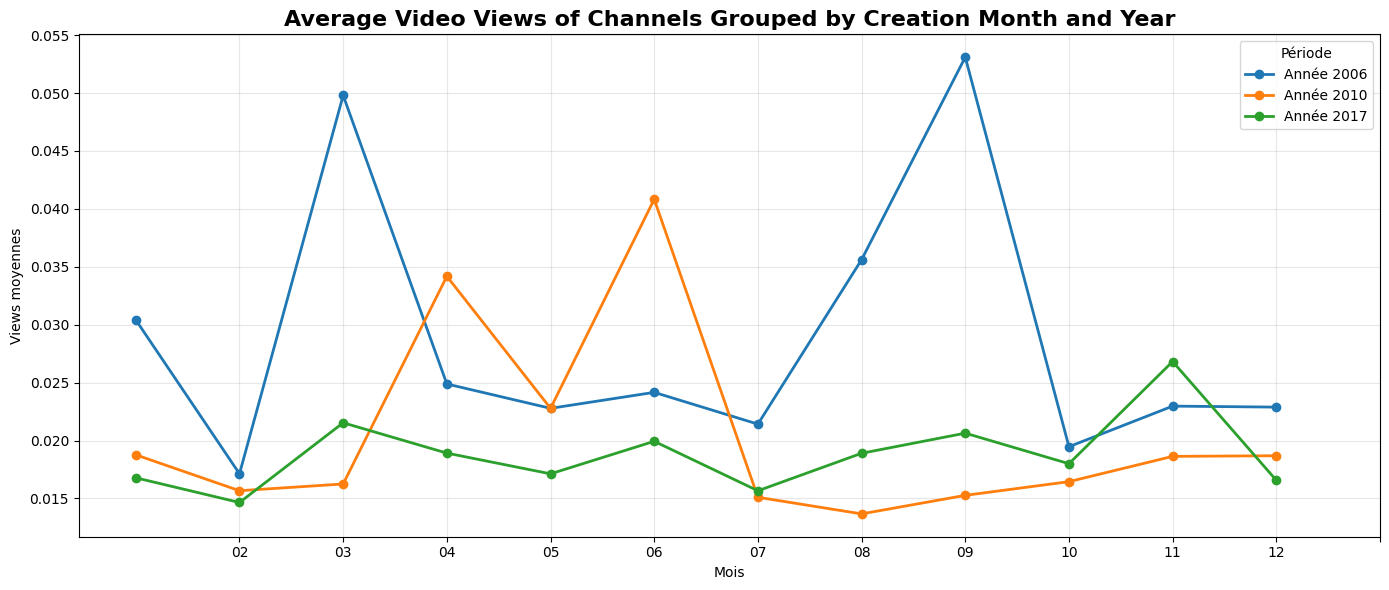

In [165]:
# keep just the years 2006, 2010, 2017
periode_2006_2010_2017 = courbe_periode1[
    courbe_periode.index.isin([2006, 2010, 2017])
]

# Tracé
plt.figure(figsize=(14, 6))

for annee in periode_2006_2010_2017.index:
    plt.plot(
        periode_2006_2010_2017.columns,
        periode_2006_2010_2017.loc[annee].apply(lambda x : x / 1e9),
        marker="o",
        linewidth=2,
        label=f"Année {annee}"
    )

plt.title("Average Video Views of Channels Grouped by Creation Month and Year", fontsize=16, weight="bold")
plt.xlabel("Mois")
plt.ylabel("Views moyennes")

plt.xticks(range(1, 13) , )

plt.legend(title="Période")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

<div style="
    background: linear-gradient(135deg, #f8fafc, #eef2ff);
    border-left: 6px solid #4f46e5;
    padding: 22px;
    border-radius: 14px;
    font-family: 'Segoe UI', Arial, sans-serif;
    box-shadow: 0 4px 14px rgba(0,0,0,0.08);
">

<h2 style="color:purple; margin-bottom:10px;">
     Heatmap temporelle
</h2>

</div>

In [166]:
# create dynamic table
pivot_heatmap = data.pivot_table(
    values="video views",
    index="created_year",
    columns="created_month",
    aggfunc="mean"
)

In [167]:
pivot_heatmap.head()

created_month,01,02,03,04,05,06,07,08,09,10,11,12
created_year,,,,,,,,,,,,
2005,NaN,NaN,NaN,NaN,NaN,7.719450,NaN,NaN,12.388146,14.049172,14.495019,27.496747
2006,8.516085,3.347126,25.963440,15.372657,8.527945,15.256363,8.804935,17.113625,45.065967,9.696982,11.475295,10.878863
2007,13.342716,15.625374,6.575413,12.989582,25.351023,14.932086,11.714763,101.000000,9.353054,5.645433,6.167161,12.607489
2008,13.131282,12.221181,11.201338,9.821134,13.123631,18.671315,20.026062,8.870790,9.033826,NaN,15.676229,NaN
2009,NaN,8.526200,8.258300,7.102966,19.269294,10.031079,6.662000,11.291329,14.949305,11.778895,11.439554,14.643284


In [168]:
mois = {
    "01": "Jan",
    "02": "Fév",
    "03": "Mar",
    "04": "Avr",
    "05": "Mai",
    "06": "Juin",
    "07": "Juil",
    "08": "Aoû",
    "09": "Sep",
    "10": "Oct",
    "11": "Nov",
    "12": "Déc"
}

In [169]:
# Transform columns [ months ] to abbreviate format
pivot_heatmap.columns = [mois[m] for m in pivot_heatmap.columns]

In [170]:
# work with data comming form years 2006 , 2010 , 2017
pivot_heatmap_2006_2010_2017 = pivot_heatmap[pivot_heatmap.index.isin([2006,2010,2017])]

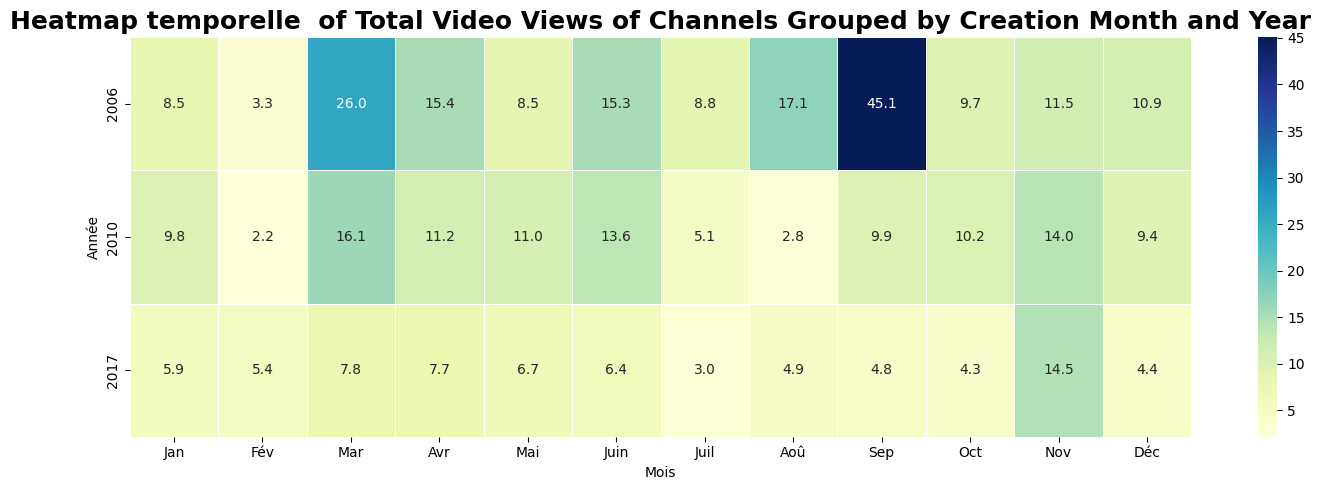

In [171]:

plt.figure(figsize=(14, 5))
sns.heatmap(pivot_heatmap_2006_2010_2017, annot=True, fmt=".1f", cmap="YlGnBu", linewidths=0.5)

plt.title("Heatmap temporelle  of Total Video Views of Channels Grouped by Creation Month and Year", fontsize=18, weight="bold")

plt.xlabel("Mois")
plt.ylabel("Année")

plt.tight_layout()
plt.show()

---
- La heatmap confirme que l'ancienneté est le principal déterminant du volume de vues, avec 2006 dominant largement. Toutefois, des effets de mois existent (Mars fort, Février faible) et des pics ponctuels (Sep 2006, Nov 2017) suggèrent l'influence de chaînes individuellement très performantes sur l'agrégat.
---

## Conclusion
---
- Cette analyse montre que le nombre de video views est fortement influencé par l’année de création des chaînes, car les chaînes les plus anciennes ont eu plus de temps pour accumuler des vues. On observe également certains effets liés au mois de création, notamment un pic régulier en mars et une baisse en février. Cependant, ces variations ne sont pas toujours uniformes selon les années, comme le montre le pic exceptionnel de septembre 2006. Ainsi, on peut parler d’effets de mois, mais pas d’une saisonnalité totalement généralisable.
---

<div style="
    background: linear-gradient(135deg, #f8fafc, #eef2ff);
    border-left: 6px solid #4f46e5;
    padding: 22px;
    border-radius: 14px;
    font-family: 'Segoe UI', Arial, sans-serif;
    box-shadow: 0 4px 14px rgba(0,0,0,0.08);
">

<h2 style="color:purple; margin-bottom:10px;">
     Geospatial visualizations
</h2>

</div>

In [172]:
df.dropna(subset=["Latitude","Longitude","Country"] , inplace =True)


In [173]:
grouped = df.groupby("Country" ,as_index=False).agg({
    "video views" : "sum",
    "Latitude" : lambda x : x.mode().iloc[0] ,
    "Longitude" : lambda x : x.mode().iloc[0]
}).sort_values(by="video views" , ascending=False)

grouped.head()


,Country,video views,Latitude,Longitude
45,United States,3.681592e+12,37.090240,-95.712891
17,India,2.281048e+12,20.593684,78.962880
5,Brazil,4.787683e+11,-14.235004,-51.925280
44,United Kingdom,4.305665e+11,55.378051,-3.435973
40,Thailand,2.643180e+11,15.870032,100.992541


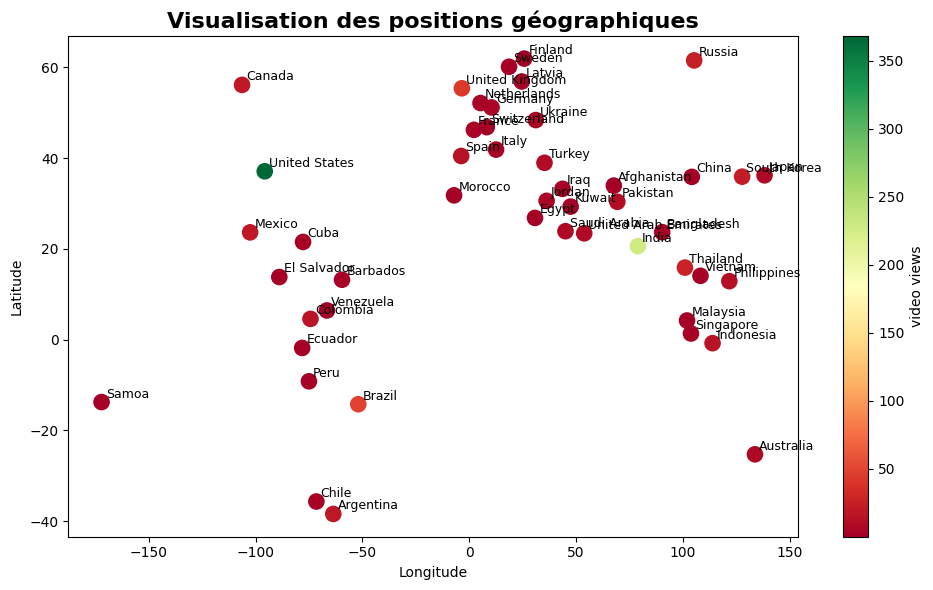

In [174]:
fig, ax = plt.subplots(1, 1, figsize=(10, 6))

scatter = ax.scatter(
    grouped["Longitude"], grouped["Latitude"],
    c=grouped["video views"] / 1e10,
    s=120,
    cmap="RdYlGn"
)

for i in range(len(grouped)):
    ax.text(
        grouped.iloc[i]["Longitude"] + 2,
        grouped.iloc[i]["Latitude"] + 1,
        grouped.iloc[i]["Country"],
        fontsize=9
    )

cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label("video views")

ax.set_title("Visualisation des positions géographiques", fontsize=16, fontweight="bold")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
plt.tight_layout()
plt.show()

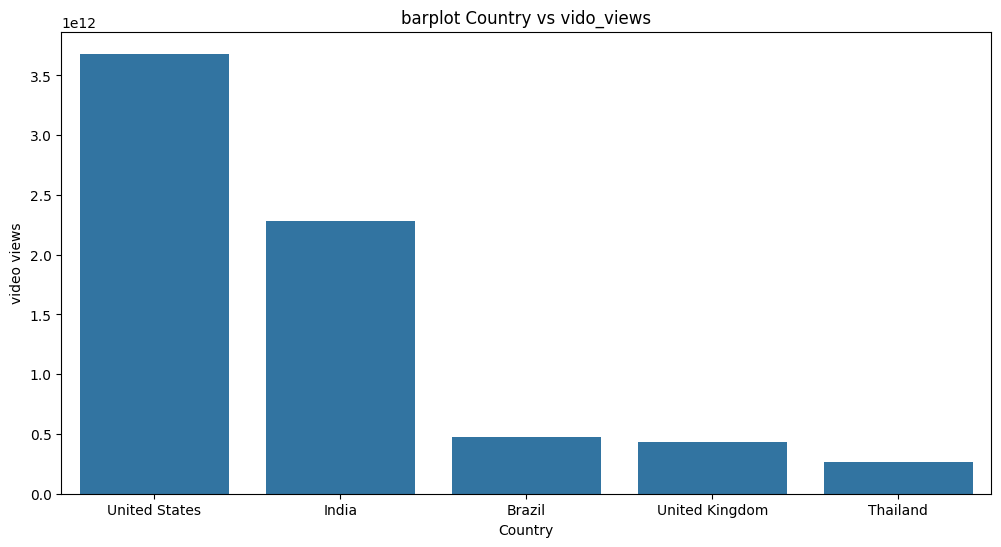

In [175]:
#bar chart
plt.figure(figsize=(12, 6))
sns.barplot(x="Country",y="video views",data=grouped.iloc[:5])
plt.title("barplot Country vs vido_views")
plt.show()

In [176]:
import geopandas as gpd
import geodatasets
from shapely.geometry import LineString


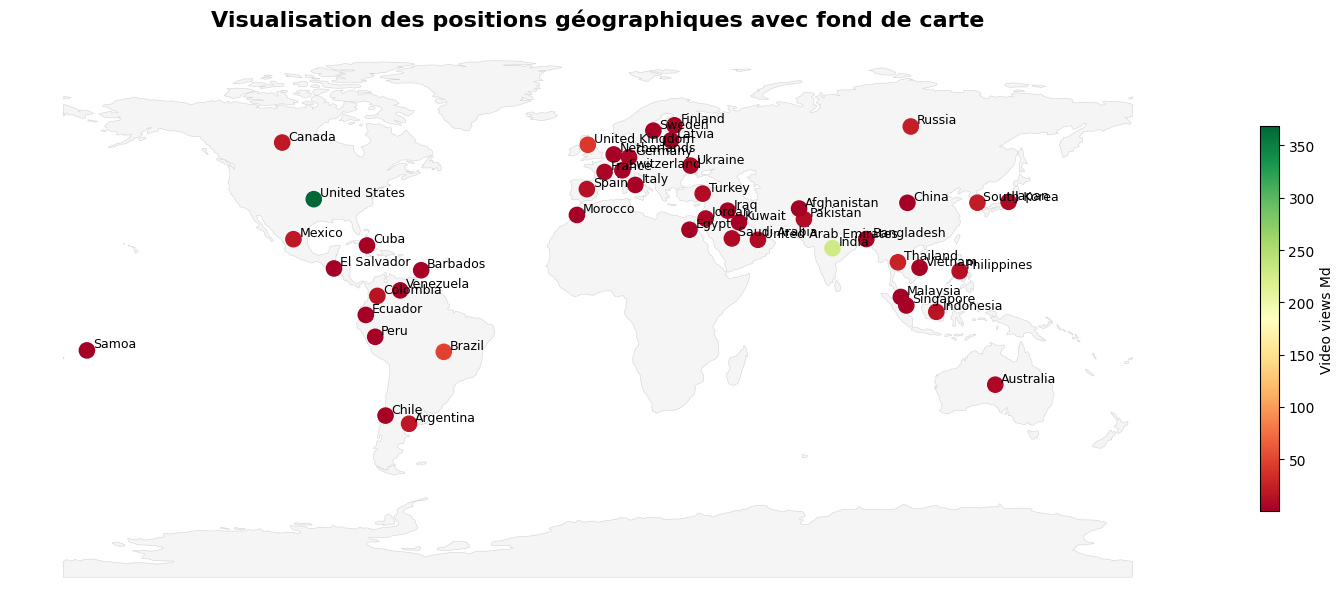

In [177]:
#Conversion en GeoDataFrame
gdf = gpd.GeoDataFrame(
    grouped,
    geometry=gpd.points_from_xy(grouped["Longitude"], grouped["Latitude"]),
    crs="EPSG:4326"
)
#Chargement du fond de carte
world = gpd.read_file(geodatasets.get_path("naturalearth.land"))

#Visualisation avec fond de carte
fig, ax = plt.subplots(1, 1, figsize=(15, 8))

# fond de carte
world.plot(
    ax=ax,
    color="whitesmoke",
    edgecolor="lightgray",
    linewidth=0.4
)

# points
scatter = ax.scatter(
    gdf["Longitude"], gdf["Latitude"], c=gdf["video views"]/1e10,
    s=120,
    cmap="RdYlGn" 
 )

# noms des villes
for i in range(len(gdf)):
    ax.text(
        gdf.iloc[i] ["Longitude"] + 2,
        gdf.iloc[i] ["Latitude"] + 1,
        gdf.iloc[i] ["Country"],
        fontsize=9
    )

# barre de couleur
cbar = plt.colorbar(scatter, ax=ax, shrink=0.5)
cbar.set_label("Video views Md")

ax.set_title("Visualisation des positions géographiques avec fond de carte", fontsize=16, fontweight="bold")
ax.set_axis_off()
plt.tight_layout()
plt.show()



Colonnes disponibles dans le fond de carte :
Index(['featurecla', 'scalerank', 'LABELRANK', 'SOVEREIGNT', 'SOV_A3',
       'ADM0_DIF', 'LEVEL', 'TYPE', 'TLC', 'ADMIN',
       ...
       'FCLASS_TR', 'FCLASS_ID', 'FCLASS_PL', 'FCLASS_GR', 'FCLASS_IT',
       'FCLASS_NL', 'FCLASS_SE', 'FCLASS_BD', 'FCLASS_UA', 'geometry'],
      dtype='object', length=169)

Données fusionnées :
                         ADMIN   video views
0                         Fiji           NaN
1  United Republic of Tanzania           NaN
2               Western Sahara           NaN
3                       Canada  1.913206e+11
4     United States of America           NaN


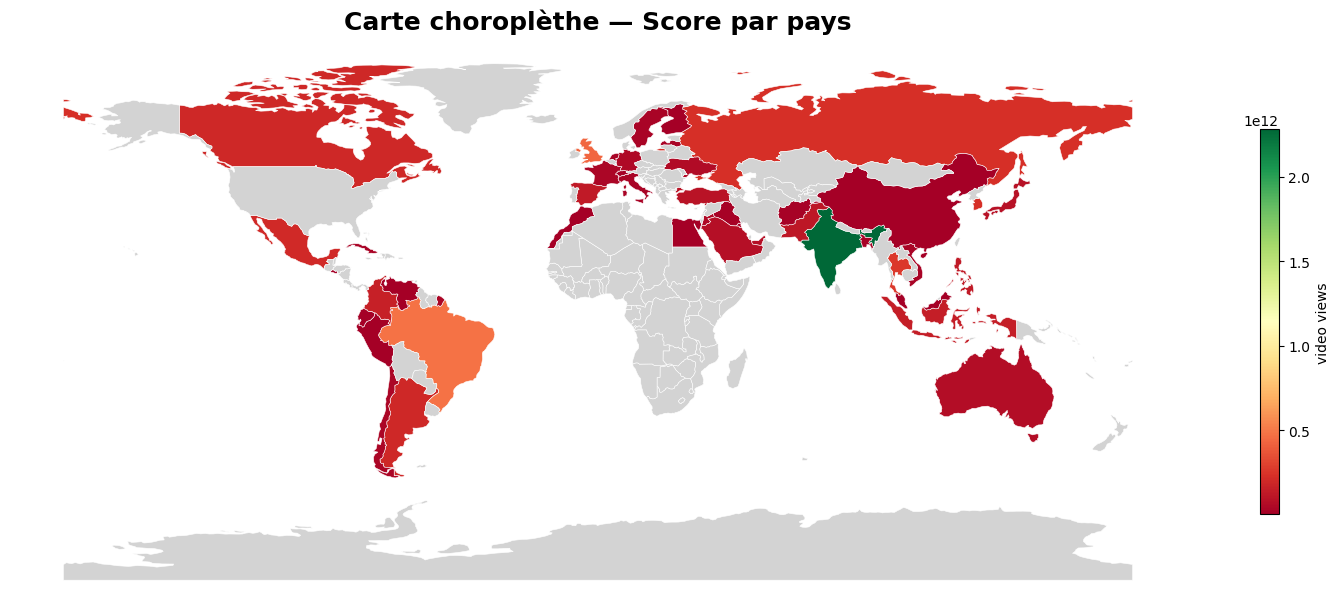

In [178]:
# Fichier Natural Earth (pays du monde)
url = "https://naciscdn.org/naturalearth/110m/cultural/ne_110m_admin_0_countries.zip"
world = gpd.read_file(url)

print("\nColonnes disponibles dans le fond de carte :")
print(world.columns)

# Fusion des données
# Dans ce jeu, le nom du pays est dans la colonne 'ADMIN'
world_merged = world.merge(grouped, left_on="ADMIN", right_on="Country", how="left")

print("\nDonnées fusionnées :")
print(world_merged[["ADMIN", "video views"]].head())

# Visualisation choroplèthe
fig, ax = plt.subplots(1, 1, figsize=(15, 8))

world_merged.plot(
    column="video views",
    ax=ax,
    cmap="RdYlGn",
    legend=True,
    legend_kwds={
        "label": "video views",
        "orientation": "vertical",
        "shrink": 0.5
    },
    missing_kwds={
        "color": "lightgrey",
        "label": "Pas de données"
    },
    edgecolor="white",
    linewidth=0.4
)

ax.set_title("Carte choroplèthe — Score par pays", fontsize=18, fontweight="bold")
ax.set_axis_off()
plt.tight_layout()
plt.show()